In [20]:
pip install yfinance -q

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as norm
import yfinance as yf
import pandas as pd
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
warnings.filterwarnings('ignore')

In [22]:
ticker = 'F'
df = yf.download(ticker, start='1986-02-07', end='2025-02-21', interval = '1d')
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,F,F,F,F,F
Date,,,,,
1986-02-07,0.836671,0.846438,0.815510,0.820393,9279015
1986-02-10,0.859460,0.862715,0.838299,0.839927,16294174
1986-02-11,0.892015,0.892015,0.864343,0.864343,15567505
1986-02-12,0.892015,0.896898,0.883876,0.888759,11524787
1986-02-13,0.918060,0.918060,0.903410,0.908293,21208238


In [23]:
df = df[['Close']]
df = df.rename(columns={'Close': 'value'})
df.index.name = 'Date'
df.head();

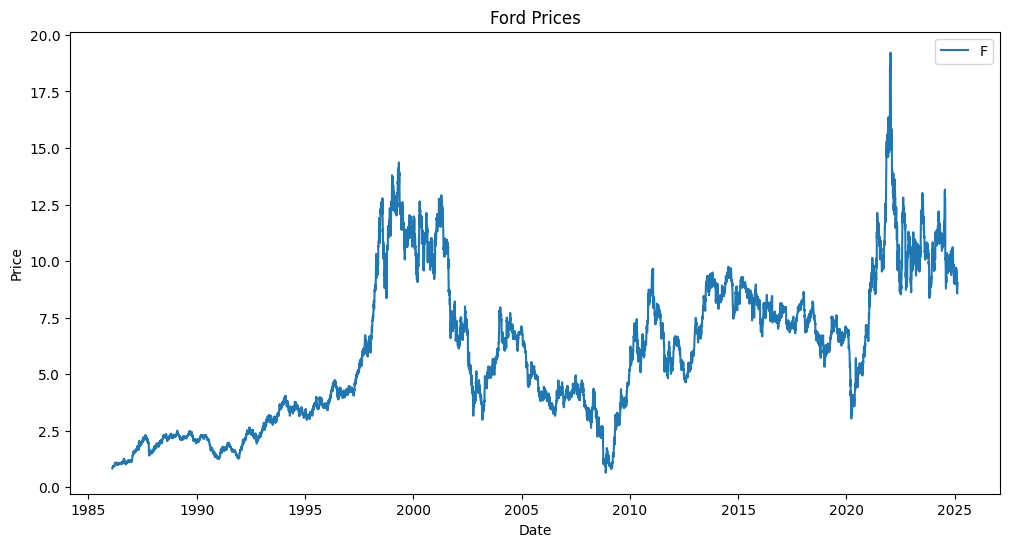

In [24]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['value'], label = 'F')
plt.title("Ford Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Anomaly Detection

In [25]:
df['Z-Score'] = zscore(df[('value', 'F')])
threshold = 2
df['Anomaly'] = df['Z-Score'].abs() > 3

In [26]:
X = df[['value']].values
isolationforest = IsolationForest(contamination=0.01, random_state=42)
df['Anomaly Isolation Forest'] = isolationforest.fit_predict(X) == -1

In [27]:
decomposition = seasonal_decompose(df[('value', 'F')], model='additive', period=30)
df['Residuals'] = decomposition.resid


residual_threshold = 10
df['Anomaly Residuals'] = df['Residuals'].abs() > residual_threshold

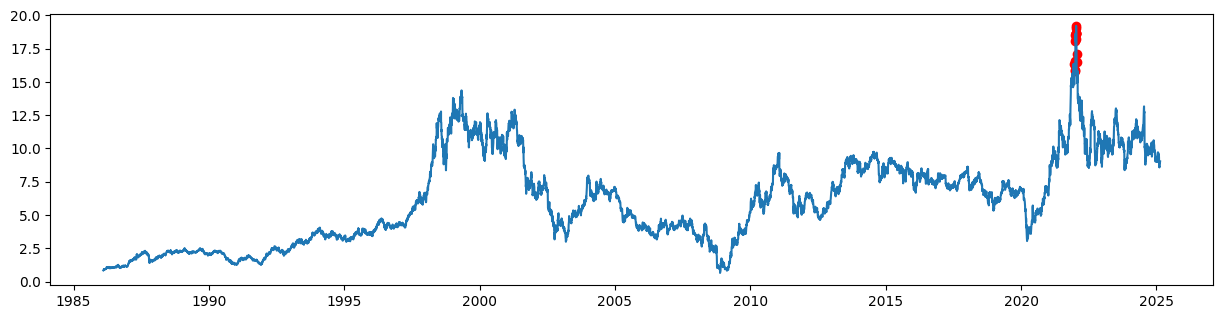

In [28]:
plt.figure(figsize=(15, 12))
plt.subplot (3, 1, 1)
plt.plot(df.index, df[('value', 'F')], label='Stock Price')
plt.scatter(df.index[df['Anomaly']], df[('value', 'F')][df['Anomaly']], color='red', label='Anomalies')

In [29]:
df[('value', 'F')][df['Anomaly']]

,value
,F
Date,
2021-12-10,16.357164
2021-12-27,15.861495
2021-12-31,15.838620
2022-01-03,16.601189
2022-01-04,18.538118
2022-01-05,18.042446
2022-01-06,18.652506
2022-01-07,18.637259


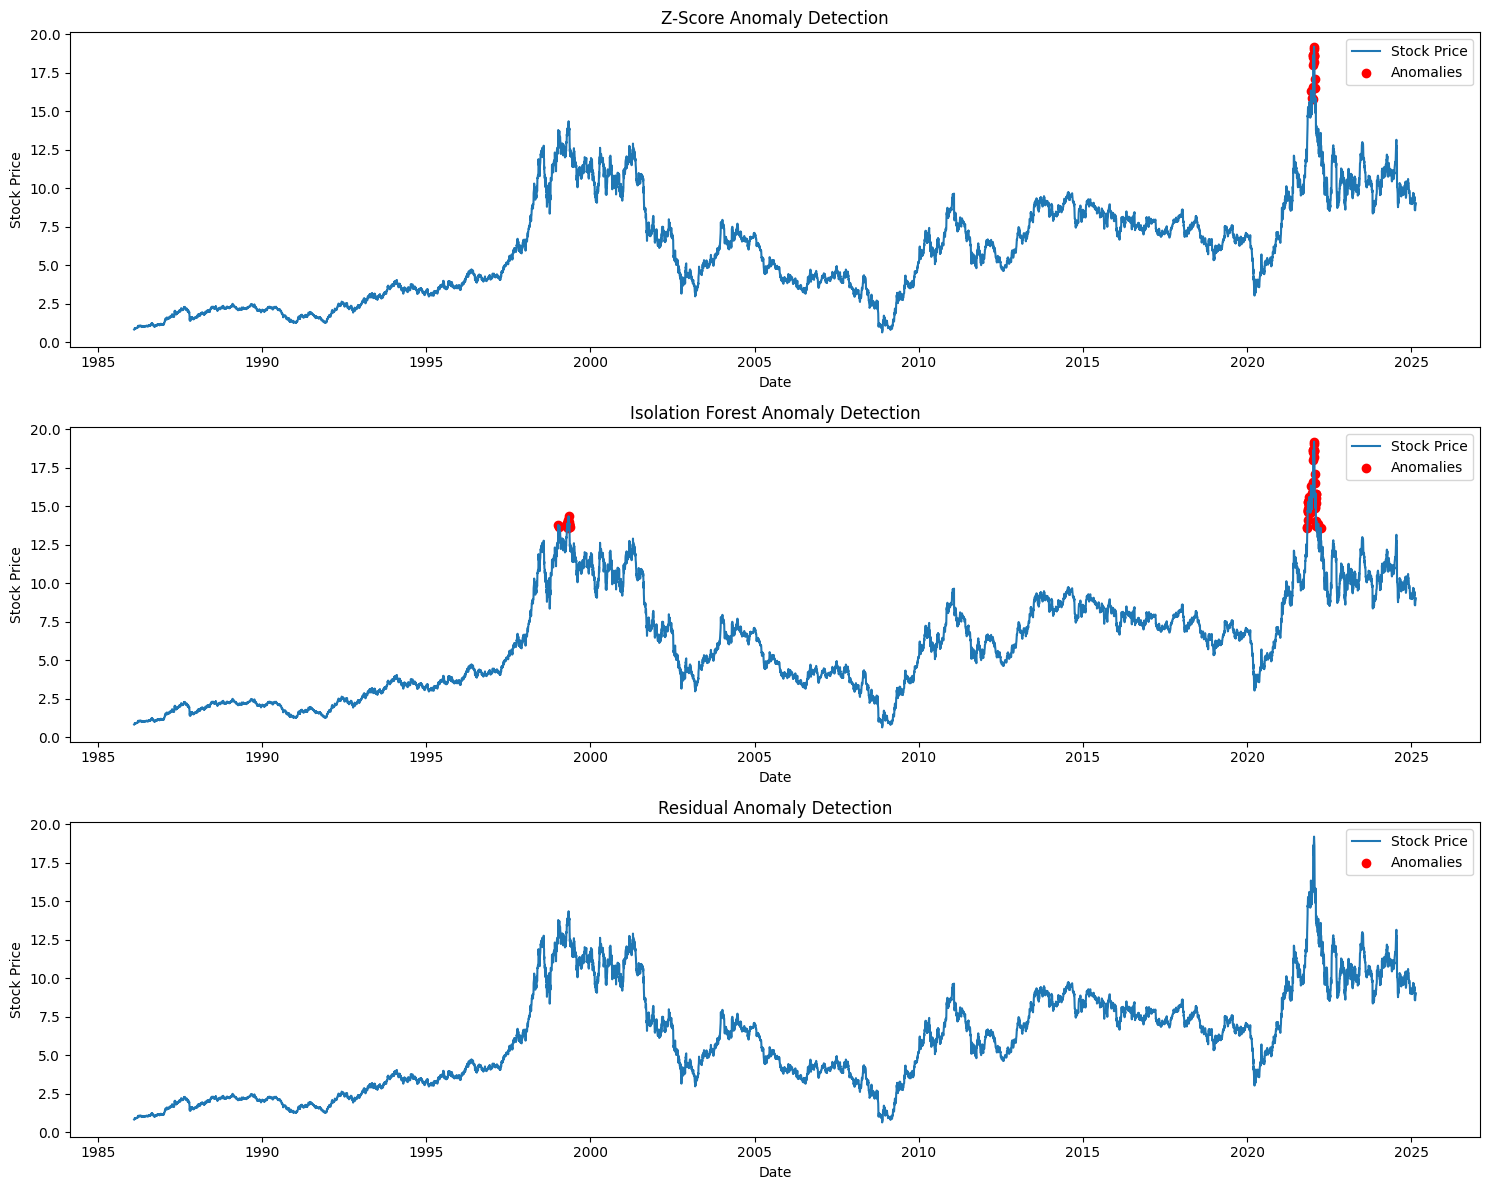

In [30]:
plt.figure(figsize=(15, 12))


plt.subplot(3, 1,1)
plt.plot(df.index, df[('value', 'F')], label='Stock Price')
plt.scatter(df.index[df['Anomaly']], df[('value', 'F')][df['Anomaly']], color='red', label='Anomalies')
plt.title('Z-Score Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()



plt.subplot(3, 1,2)
plt.plot(df.index, df[('value', 'F')], label='Stock Price')
plt.scatter(df.index[df['Anomaly Isolation Forest']], df[('value', 'F')][df['Anomaly Isolation Forest']], color='red', label='Anomalies')
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()


plt.subplot(3, 1, 3)
plt.plot(df.index, df[('value', 'F')], label='Stock Price')
plt.scatter(df.index[df['Anomaly Residuals']], df[('value', 'F')][df['Anomaly Residuals']], color='red', label='Anomalies')
plt.title('Residual Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()

plt.tight_layout()
plt.show()

# LSTM implementation

In [31]:
df = yf.download("F", start="2018-01-01", end="2024-01-01")

df["return"] = df["Close"].pct_change()
df["vol"] = df["return"].rolling(10).std()
df = df.dropna()

features = ["return", "vol"]
data = df[features].values
target = df["return"].shift(-1).dropna().values
data = data[:-1]

[*********************100%***********************]  1 of 1 completed


In [32]:
SEQ_LEN = 30

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X, y = make_sequences(data, target, SEQ_LEN)

In [33]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)


In [35]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

In [36]:
model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.1003e-04 - val_loss: 0.0011
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.9476e-04 - val_loss: 0.0010
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 8.0782e-04 - val_loss: 0.0011
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 8.4966e-04 - val_loss: 0.0010
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.6583e-04 - val_loss: 0.0010
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.7484e-04 - val_loss: 0.0012
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.5569e-04 - val_loss: 0.0010
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.6060e-04 - val_loss: 0.0011
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.3227e-04 - val_loss: 0.0010
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.0831e-04 - val_loss: 0.0015
Epoch 12/30
30/30 ━━━━━

In [37]:
preds = model.predict(X_test).flatten()

ic = np.corrcoef(preds, y_test)[0,1]
print("IC:", ic)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
IC: 0.07191606088544913


In [38]:
signal = np.sign(preds)
pnl = signal * y_test
sharpe = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
print("Sharpe:", sharpe)

Sharpe: 0.368419262240088
